In [1]:
import os
import shutil
import sys
import subprocess
import json
from pathlib import Path

In [2]:
# Load example params
params_path = Path("params.json")  # change to the correct filename or absolute path
if not params_path.exists():
    raise FileNotFoundError(f"JSON file not found: {params_path}")

with params_path.open("r", encoding="utf-8") as f:
    params = json.load(f)

print("Loaded params:", params)

Loaded params: {'seed': 42, 'metadata': {'year': 2025, 'location': 'Davis', 'plant_type': 'cowpea', 'dap': {'distribution': {'type': 'uniform', 'params': {'min': 10, 'max': 10}}}}, 'environment': {'soil': {'soil_color': [0.61, 0.58, 0.55], 'use_obj_ground': False, 'rotate_obj': 90.0, 'obj_file_path': '../../../obj/dirt_rocks.obj', 'spectral_data': {'reflectivity': {'distribution': {'type': 'categorical', 'params': {'categories': ['soil_reflectivity_0003']}}}}, 'specular_exponent': {'distribution': {'type': 'uniform', 'params': {'min': 2.0, 'max': 4.0}}}}, 'sun': {'elevation_degrees': {'distribution': {'type': 'uniform', 'params': {'min': 0.0, 'max': 90.0}}}, 'azimuth_degrees': {'distribution': {'type': 'uniform', 'params': {'min': 0.0, 'max': 360.0}}}, 'shadow': True}}, 'field': {'layout': {'mode': 'manual', 'plot_size_x': 3.0, 'plot_size_y': 6.0, 'plot_size_z': 0.2, 'num_beds': 1, 'num_rows': 1, 'sampling': {'num_beds': {'distribution': {'type': 'uniform', 'params': {'min': 1, 'max': 

In [20]:
import os
import shutil
import sys
import subprocess
import json
from pathlib import Path

# DroneOrthoDataset for processing georeferenced orthophotos
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import box, mapping
import numpy as np
from pathlib import Path
from PIL import Image
import json



def calculate_required_fov(camera_height, plot_width, plot_height, image_width, image_height, margin_factor=1.1, verbose=False):
    """
    Calculate required HFOV and VFOV to cover the entire plot area.
    
    Args:
        camera_height: Camera height above ground (meters)
        plot_width: Plot width in meters (X direction)
        plot_height: Plot height in meters (Y direction)
        image_width: Image width in pixels
        image_height: Image height in pixels
        margin_factor: Safety margin to ensure full coverage (default: 1.1 = 10% margin)
    
    Returns:
        tuple: (HFOV_degrees, VFOV_degrees)
    
    Algorithm:
        For a top-down camera at height h, to see a ground distance d:
        FOV = 2 * atan(d / (2 * h))
        
        We add a margin_factor to ensure complete coverage.
    """
    import math
    
    # Calculate required FOV to see the entire plot with margin
    required_width_coverage = plot_width * margin_factor
    required_height_coverage = plot_height * margin_factor
    
    # Calculate FOV angles in radians
    # FOV = 2 * atan(ground_distance / (2 * camera_height))
    HFOV_rad = 2.0 * math.atan(required_width_coverage / (2.0 * camera_height))
    VFOV_rad = 2.0 * math.atan(required_height_coverage / (2.0 * camera_height))
    
    # Convert to degrees
    HFOV_deg = math.degrees(HFOV_rad)
    VFOV_deg = math.degrees(VFOV_rad)
    
    # Verify: calculate what ground area these FOVs would actually cover
    actual_width_coverage = 2.0 * camera_height * math.tan(HFOV_rad / 2.0)
    actual_height_coverage = 2.0 * camera_height * math.tan(VFOV_rad / 2.0)
    
    # Calculate aspect ratio from image dimensions
    image_aspect_ratio = image_width / image_height
    fov_aspect_ratio = math.tan(HFOV_rad / 2.0) / math.tan(VFOV_rad / 2.0)

    if verbose:
        print(f"=== FOV Calculation Report ===")
        print(f"Camera height: {camera_height:.2f} m")
        print(f"Plot size: {plot_width:.2f} m x {plot_height:.2f} m")
        print(f"Image size: {image_width} x {image_height} pixels")
        print(f"Image aspect ratio: {image_aspect_ratio:.3f}")
        print(f"Required coverage (with {margin_factor:.1f}x margin): {required_width_coverage:.2f} m x {required_height_coverage:.2f} m")
        print(f"Calculated HFOV: {HFOV_deg:.2f}°")
        print(f"Calculated VFOV: {VFOV_deg:.2f}°")
        print(f"FOV aspect ratio: {fov_aspect_ratio:.3f}")
        print(f"Actual ground coverage: {actual_width_coverage:.2f} m x {actual_height_coverage:.2f} m")
        print(f"Coverage check: Width {actual_width_coverage/plot_width:.2f}x, Height {actual_height_coverage/plot_height:.2f}x")
    
    return HFOV_deg, VFOV_deg


def dem_to_obj(dem_path, obj_path=None, scale_z=1.0, subsample=1, normalize=True, debug=False):
    """
    Convert a Digital Elevation Model (DEM) TIFF to an OBJ file with proper normalization
    
    Args:
        dem_path: Path to DEM TIFF file
        obj_path: Output OBJ file path (default: dem_path with .obj extension)
        scale_z: Scale factor for Z/elevation values
        subsample: Subsample factor to reduce mesh density (1=full res, 2=half, etc.)
        normalize: If True, normalize elevations to 0-1 range and shift to ground level
    
    Returns:
        Path to generated OBJ file
    """
    import matplotlib.pyplot as plt
    
    dem_path = Path(dem_path)
    
    if obj_path is None:
        obj_path = dem_path.with_suffix('.obj')
    else:
        obj_path = Path(obj_path)
    
    # Read DEM data
    with rasterio.open(dem_path) as src:
        dem_data = src.read(1).astype(np.float32)
        height, width = dem_data.shape
        transform = src.transform
        scale_xy = abs(transform.a)
        nodata = src.nodata
    
    # Create mask for valid data
    if nodata is not None:
        valid_mask = (dem_data != nodata)
    else:
        valid_mask = ~np.isnan(dem_data)
    
    if not np.any(valid_mask):
        raise ValueError("No valid elevation data found in DEM")
    
    valid_data = dem_data[valid_mask]
    
    if debug:
        print(f"DEM Statistics (before processing):")
        print(f"  Min: {valid_data.min():.2f}")
        print(f"  Max: {valid_data.max():.2f}")
        print(f"  Mean: {valid_data.mean():.2f}")
        print(f"  Std: {valid_data.std():.2f}")
        print(f"  Valid pixels: {np.sum(valid_mask)} / {dem_data.size} ({100*np.sum(valid_mask)/dem_data.size:.1f}%)")
    
    dem_min = valid_data.min()
    dem_max = valid_data.max()
    dem_range = dem_max - dem_min
    dem_normalized = dem_data.copy()

    # if 0:
    #     # Make max point to 0
    #     dem_normalized[valid_mask] = (dem_data[valid_mask] - dem_max)
    # else:
    #     # Make plant locations to 0m
    #     # To to that, use project matrix to 3D points on the plant cetners to be 0
    
    # Subsample if requested
    if subsample > 1:
        dem_normalized = dem_normalized[::subsample, ::subsample]
        valid_mask = valid_mask[::subsample, ::subsample]
        height, width = dem_normalized.shape
        scale_xy *= subsample
        
        if debug:
            print(f"\nSubsampled to: {width}x{height} pixels")
    
    if debug:
        print(f"Generating OBJ from DEM: {width}x{height} pixels")
        print(f"Scale XY: {scale_xy:.6f}, Scale Z: {scale_z:.6f}")
    
    # Write OBJ file - only vertices with valid data
    vertex_count = 0
    vertex_map = {}  # Map (y, x) -> vertex index
    
    with open(obj_path, 'w') as f:
        f.write(f"# OBJ file generated from DEM: {dem_path.name}\n")
        f.write(f"# Resolution: {width}x{height}\n")
        f.write(f"# Original elevation range: {valid_data.min():.2f} to {valid_data.max():.2f}\n")
        f.write(f"# Scale XY: {scale_xy:.6f}, Scale Z: {scale_z:.6f}\n")
        f.write(f"# Normalized: {normalize}\n")
        f.write(f"# NoData value: {nodata}\n\n")
        
        # Write vertices (only for valid data)
        f.write("# Vertices\n")
        for y in range(height):
            for x in range(width):
                if valid_mask[y, x]:
                    x_coord = (x - width / 2) * scale_xy
                    y_coord = (y - height / 2) * scale_xy
                    z_coord = dem_normalized[y, x] * scale_z
                    f.write(f"v {x_coord:.6f} {y_coord:.6f} {z_coord:.6f}\n")
                    vertex_map[(y, x)] = vertex_count + 1  # OBJ uses 1-based indexing
                    vertex_count += 1
        
        # Write texture coordinates (only for valid vertices)
        f.write("\n# Texture coordinates\n")
        for y in range(height):
            for x in range(width):
                if valid_mask[y, x]:
                    u = x / (width - 1) if width > 1 else 0.0
                    v = 1.0 - (y / (height - 1)) if height > 1 else 0.0
                    f.write(f"vt {u:.6f} {v:.6f}\n")
        
        # Write faces (triangles) - only if all 4 corners have valid data
        f.write("\n# Faces\n")
        face_count = 0
        for y in range(height - 1):
            for x in range(width - 1):
                # Check if all 4 corners have valid data
                if (valid_mask[y, x] and valid_mask[y, x+1] and 
                    valid_mask[y+1, x] and valid_mask[y+1, x+1]):
                    
                    # Get vertex indices from map
                    v1 = vertex_map[(y, x)]
                    v2 = vertex_map[(y, x+1)]
                    v3 = vertex_map[(y+1, x)]
                    v4 = vertex_map[(y+1, x+1)]
                    
                    # Two triangles per quad with texture coordinates
                    f.write(f"f {v1}/{v1} {v2}/{v2} {v3}/{v3}\n")
                    f.write(f"f {v2}/{v2} {v4}/{v4} {v3}/{v3}\n")
                    face_count += 2
    
    if debug:
        print(f"OBJ file created successfully:")
        print(f"  Vertices: {vertex_count}")
        print(f"  Faces: {face_count}")
        print(f"  Saved to: {obj_path}")
    
    return obj_path

In [28]:
class DroneOrthoDataset:
    def __init__(
        self,
        ortho_path=Path("/path/to/orthophoto.tif"),
        dem_path=None,  # Add DEM path parameter
        geojson_path=Path("/path/to/plot_boundaries.geojson"),
        program_path="build_release/main",
        transform=None,
        debug=False,
        use_sam=False,
        target_crs=None,
    ):
        self.ortho_path = Path(ortho_path)
        self.dem_path = Path(dem_path) if dem_path else None
        self.geojson_path = Path(geojson_path)
        
        if not self.ortho_path.exists():
            raise FileNotFoundError(f"Orthophoto not found: {self.ortho_path}")
        if self.dem_path and not self.dem_path.exists():
            raise FileNotFoundError(f"DEM not found: {self.dem_path}")
        if not self.geojson_path.exists():
            raise FileNotFoundError(f"GeoJSON not found: {self.geojson_path}")
        
        self.transform = transform
        self.program_path = program_path
        self.debug = debug
        
        # Load SAM 2.1 model
        if use_sam:
            from ultralytics import SAM
            self.SAM_model = SAM("sam2.1_b.pt")
        
        # Load orthophoto metadata
        with rasterio.open(self.ortho_path) as src:
            self.ortho_crs = src.crs
            self.ortho_transform = src.transform
            self.ortho_bounds = src.bounds
            self.ortho_shape = (src.height, src.width)
            
            if self.ortho_crs.is_geographic:
                # Auto-calculate appropriate UTM zone from image center
                if target_crs is None:
                    center_lon = (src.bounds.left + src.bounds.right) / 2
                    center_lat = (src.bounds.bottom + src.bounds.top) / 2
                    
                    # Calculate UTM zone from longitude
                    utm_zone = int((center_lon + 180) / 6) + 1
                    
                    # Determine hemisphere (north/south)
                    if center_lat >= 0:
                        target_crs = f"EPSG:326{utm_zone:02d}"  # WGS84 UTM North
                    else:
                        target_crs = f"EPSG:327{utm_zone:02d}"  # WGS84 UTM South
                    
                    if self.debug:
                        print(f"Auto-detected UTM zone {utm_zone} ({'North' if center_lat >= 0 else 'South'})")
                        print(f"Using CRS: {target_crs}")
                
                if self.debug:
                    print(f"Original CRS is geographic ({self.ortho_crs}), will reproject to {target_crs}")
                self.needs_reprojection = True
                self.working_crs = target_crs
            else:
                self.needs_reprojection = False
                self.working_crs = self.ortho_crs
                
            if not self.needs_reprojection:
                self.pixel_size_x = abs(src.transform.a)
                self.pixel_size_y = abs(src.transform.e)
                self.pixel_size = (self.pixel_size_x + self.pixel_size_y) / 2
            else:
                from rasterio.warp import calculate_default_transform
                transform, width, height = calculate_default_transform(
                    src.crs, target_crs, src.width, src.height, *src.bounds
                )
                self.pixel_size_x = abs(transform.a)
                self.pixel_size_y = abs(transform.e)
                self.pixel_size = (self.pixel_size_x + self.pixel_size_y) / 2
            
            if self.debug:
                print(f"Orthophoto CRS: {self.ortho_crs}")
                print(f"Working CRS: {self.working_crs}")
                print(f"Pixel size: {self.pixel_size:.6f} m/pixel")
                print(f"Image dimensions: {self.ortho_shape}")
        
        # Load plot boundaries from GeoJSON
        self.plots_gdf = gpd.read_file(self.geojson_path)
        
        if self.plots_gdf.crs != self.working_crs:
            if self.debug:
                print(f"Reprojecting plots from {self.plots_gdf.crs} to {self.working_crs}")
            self.plots_gdf = self.plots_gdf.to_crs(self.working_crs)
        
        # Extract plot metadata
        self._files = []
        for idx, row in self.plots_gdf.iterrows():
            plot_info = {
                'idx': idx,
                'geometry': row.geometry,
                'bed': row.get('bed', row.get('column', idx)),
                'row': row.get('row', 0),
                'properties': dict(row.drop('geometry'))
            }
            self._files.append(plot_info)
        
        if not self._files:
            raise RuntimeError(f"No plots found in {self.geojson_path}")
        
        if self.debug:
            print(f"Loaded {len(self._files)} plots from GeoJSON")
    
    def __len__(self):
        return len(self._files)
    
    def __getitem__(self, i):
        """Extract and return cropped image for a specific plot"""
        from rasterio.warp import reproject, Resampling
        
        entry = self._files[i]
        
        # Crop orthophoto to plot boundary
        with rasterio.open(self.ortho_path) as src:
            if self.needs_reprojection:
                # First, reproject the geometry back to source CRS for masking
                geom_src_crs = gpd.GeoSeries([entry['geometry']], crs=self.working_crs).to_crs(src.crs)[0]
                geom = [mapping(geom_src_crs)]
                
                # Mask and crop
                out_image, out_transform = mask(src, geom, crop=True)
                
                # Now reproject the cropped image to target CRS
                # Calculate destination shape
                from rasterio.warp import calculate_default_transform
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src.crs,
                    self.working_crs,
                    out_image.shape[2],
                    out_image.shape[1],
                    *rasterio.transform.array_bounds(out_image.shape[1], out_image.shape[2], out_transform)
                )
                
                # Create destination array
                dst_image = np.zeros((out_image.shape[0], dst_height, dst_width), dtype=out_image.dtype)
                
                # Reproject each band
                for i in range(out_image.shape[0]):
                    reproject(
                        source=out_image[i],
                        destination=dst_image[i],
                        src_transform=out_transform,
                        src_crs=src.crs,
                        dst_transform=dst_transform,
                        dst_crs=self.working_crs,
                        resampling=Resampling.bilinear
                    )
                
                out_image = dst_image
            else:
                # Original code - no reprojection needed
                geom = [mapping(entry['geometry'])]
                out_image, out_transform = mask(src, geom, crop=True)
            
            # Convert to HWC format
            out_image = np.transpose(out_image, (1, 2, 0))
            
            # Convert to PIL Image
            if out_image.shape[2] >= 3:
                img = Image.fromarray(out_image[:, :, :3].astype(np.uint8))
            else:
                img = Image.fromarray(out_image.astype(np.uint8))
        
        if self.transform:
            img = self.transform(img)
        
        return img, {
            'idx': entry['idx'],
            'bed': entry['bed'],
            'row': entry['row'],
            'geometry': entry['geometry'],
            'properties': entry['properties']
        }
    
    def list_plot_ids(self):
        """Return list of (bed, row) tuples"""
        return [(e['bed'], e['row']) for e in self._files]
        
    def localize_plants(self, idx=0, thresh=None, min_size=10, show=True, use_sam=True, histogram_norm=False):
        """
        Localize plants in a cropped plot using ExG -> SAM refinement.
        Similar to AmigaStitchDataset but works on cropped drone orthophoto.
        
        Args:
            idx: dataset index
            thresh: ExG threshold for binary mask (None for auto Otsu)
            min_size: minimum blob area in pixels
            show: if True, display image with centers and bboxes overlayed
            use_sam: if True, use SAM for refinement
            histogram_norm: if True, apply histogram equalization to improve contrast
            
        Returns:
            list of dicts with keys: 'center', 'bbox', 'mask', 'center_m'
        """
        import numpy as np
        import cv2
        from skimage import measure
        import matplotlib.pyplot as plt
        import matplotlib.patches as patches
        
        # Step 1: Load cropped image for this plot
        img, meta = self[idx]
        img_np = np.array(img)
        self.img_np = img_np
        # Apply histogram normalization if requested
        if histogram_norm:
            # Convert to LAB color space for better histogram equalization
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            
            # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to L channel
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l_equalized = clahe.apply(l)
            
            # Merge channels and convert back to RGB
            lab_equalized = cv2.merge([l_equalized, a, b])
            img_np = cv2.cvtColor(lab_equalized, cv2.COLOR_LAB2RGB)
            
            if self.debug:
                print("Applied histogram normalization (CLAHE)")
        
        self.img_shape = img_np.shape
        
        # Get plot shortest dimension in meters
        entry = self._files[idx]
        geom = entry['geometry']
        bounds = geom.bounds  # (minx, miny, maxx, maxy) in CRS units (meters)
        plot_width_m = bounds[2] - bounds[0]
        plot_height_m = bounds[3] - bounds[1]
        plot_shortest_len = min(plot_width_m, plot_height_m)
        
        if self.debug:
            print(f"Plot dimensions: {plot_width_m:.2f}m x {plot_height_m:.2f}m")
            print(f"Plot shortest dimension: {plot_shortest_len:.2f}m")
        
        # Step 2: Compute ExG and binary mask
        r, g, b = img_np[..., 0], img_np[..., 1], img_np[..., 2]
        denom = (r + g + b).astype(np.float32) + 1e-6
        exg = np.clip((2.0 * g - r - b) / denom, -1, 1)
        
        # Apply Gaussian filtering
        exg_blurred = cv2.GaussianBlur(exg.astype(np.float32), (3, 3), 0)

        if thresh is None:
            # Auto threshold with Otsu
            exg_norm = ((exg_blurred + 1) * 127.5).astype(np.uint8)
            thresh_val, bin_mask = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            thresh = (thresh_val / 127.5) - 1
            if self.debug:
                print(f"Auto threshold (Otsu): {thresh:.3f}")
        else:
            bin_mask = (exg_blurred > thresh).astype(np.uint8) * 255
        
        # Morphological operations
        kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small, iterations=2)
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, kernel_large, iterations=2)
        bin_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel_small)
        
        # Remove small components
        labels = measure.label(bin_mask, connectivity=2)
        cleaned = np.zeros_like(bin_mask)
        for prop in measure.regionprops(labels):
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            if max(h, w) >= min_size:
                coords = prop.coords
                cleaned[coords[:, 0], coords[:, 1]] = 255
        
        # Step 3: Extract blob centers
        labeled = measure.label(cleaned, connectivity=2)
        props = measure.regionprops(labeled)
        
        all_centers = []
        blob_info = []
        all_segmented_bboxes = []
        
        for prop in props:
            y1, x1, y2, x2 = prop.bbox
            h, w = y2 - y1, x2 - x1
            
            if w >= h:
                side = h
                n = int(np.ceil(w / side))
                seg_w = w // n
                for i in range(n):
                    seg_x1 = x1 + i * seg_w
                    seg_x2 = min(x1 + (i + 1) * seg_w, x2)
                    seg_y1 = y1
                    seg_y2 = y2
                    all_segmented_bboxes.append((seg_x1, seg_y1, seg_x2, seg_y2))
                    cx = (seg_x1 + seg_x2) / 2
                    cy = (y1 + y2) / 2.0
                    all_centers.append([cx, cy])
                    blob_info.append(prop.label)
            else:
                # Handle vertical blobs (h > w) - split into vertical segments
                side = w
                n = int(np.ceil(h / side))
                seg_h = h // n
                for i in range(n):
                    seg_x1 = x1
                    seg_x2 = x2
                    seg_y1 = y1 + i * seg_h
                    seg_y2 = min(y1 + (i + 1) * seg_h, y2)
                    all_segmented_bboxes.append((seg_x1, seg_y1, seg_x2, seg_y2))
                    cx = (x1 + x2) / 2.0
                    cy = (seg_y1 + seg_y2) / 2
                    all_centers.append([cx, cy])
                    blob_info.append(prop.label)

        

        
        # Step 4: Refine with SAM or use ExG-based
        if use_sam:
            # Save temporary cropped image for SAM
            temp_path = self.ortho_path.parent / f"temp_plot_{idx}.jpg"
            img.save(temp_path)
            
            points = all_centers
            labels = [1] * len(points)
            
            results = self.SAM_model(str(temp_path), points=points, labels=labels)
            
            refined_plants = []
            for i, result in enumerate(results):
                if result.masks is None:
                    continue
                
                for mask_tensor in result.masks.data:
                    mask = mask_tensor.cpu().numpy().astype(bool)
                    
                    ys, xs = np.where(mask)
                    if ys.size == 0:
                        continue
                    
                    bbox = (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))
                    center = [(bbox[0] + bbox[2]) / 2.0, (bbox[1] + bbox[3]) / 2.0]
                    
                    refined_plants.append({
                        'center': center,
                        'bbox': bbox,
                        'mask': mask
                    })
            
            # Clean up temp file
            temp_path.unlink()
        else:
            # Use ExG-based centers
            refined_plants = []
            for i in range(len(all_centers)):
                seg_bbox = all_segmented_bboxes[i]
                prop_label = blob_info[i]
                full_mask = (labeled == prop_label).astype(bool)
                seg_x1, seg_y1, seg_x2, seg_y2 = seg_bbox
                
                seg_mask = full_mask[seg_y1:seg_y2, seg_x1:seg_x2]
                ys, xs = np.where(seg_mask)
                
                if ys.size > 0:
                    center = [np.mean(xs) + seg_x1, np.mean(ys) + seg_y1]
                    x1_adj = xs.min() + seg_x1
                    y1_adj = ys.min() + seg_y1
                    x2_adj = xs.max() + seg_x1
                    y2_adj = ys.max() + seg_y1
                    bbox = (x1_adj, y1_adj, x2_adj, y2_adj)
                    
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                    mask_full[seg_y1:seg_y2, seg_x1:seg_x2] = seg_mask
                else:
                    center = [(seg_x1 + seg_x2) / 2.0, (seg_y1 + seg_y2) / 2.0]
                    bbox = seg_bbox
                    mask_full = np.zeros_like(img_np[:, :, 0], dtype=bool)
                
                refined_plants.append({
                    'center': center,
                    'bbox': bbox,
                    'mask': mask_full
                })
        
        # Convert to local coordinates (meters) relative to plot center
        factor = self.pixel_size  # meters per pixel
        plot_center_x = self.img_shape[1] / 2
        plot_center_y = self.img_shape[0] / 2
        
        for plant in refined_plants:
            # Convert pixel coordinates to meters, centered at plot origin
            center_scaled_x = (plant['center'][0] - plot_center_x) * factor
            center_scaled_y = -(plant['center'][1] - plot_center_y) * factor
            plant['center_m'] = [center_scaled_x, center_scaled_y]
        
        # Step 5: Visualize if requested
        if show:
            fig, ax = plt.subplots(1, 4, figsize=(12, 12))
            
            ax[0].imshow(img_np)
            ax[0].set_title('Image', fontsize=12)
            ax[0].axis('off')

            ax[1].imshow(exg, vmin=0, vmax=4)
            ax[1].set_title('ExG Index', fontsize=12)
            ax[1].axis('off')
            
            ax[2].imshow(cleaned, cmap='gray')
            ax[2].axis('off')
            ax[2].set_title(f'ExG Binary Mask (thresh={thresh:.3f}, min_size={min_size})', fontsize=12)
            
            ax[3].imshow(img_np)
            ax[3].axis('off')
            
            # Draw initial centers
            for i, (cx, cy) in enumerate(all_centers):
                ax[3].plot(cx, cy, 'bo', markersize=8, markerfacecolor='none', 
                          markeredgewidth=2, label='Initial Centers' if i == 0 else "")
            
            # Draw refined centers and bboxes
            for i, plant in enumerate(refined_plants):
                cx, cy = plant['center']
                ax[3].plot(cx, cy, 'r+', markersize=10, markeredgewidth=2, 
                          label='Refined Centers' if i == 0 else "")
                
                x1, y1, x2, y2 = plant['bbox']
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor='yellow', facecolor='none'
                )
                ax[3].add_patch(rect)
            
            title = f"Plot {meta['bed']}-{meta['row']}: {len(refined_plants)} plants"
            if use_sam:
                title += " (SAM)"
            ax[3].set_title(title, fontsize=12)
            ax[3].legend()
            plt.tight_layout()
            plt.show()
        
        if len(all_centers) == 0:
            print("No plant centers detected.")
            return []
        
        return refined_plants
    
    def crop_dem_to_plot(self, idx, output_dir=None, match_rgb_resolution=True):
        """
        Crop DEM to plot boundary and save as TIFF
        
        Args:
            idx: dataset index
            output_dir: Output directory for cropped DEM (default: ortho_path parent / "dem_crops")
            match_rgb_resolution: If True, resize DEM to match RGB image resolution
            
        Returns:
            Path to cropped DEM TIFF file
        """
        import matplotlib.pyplot as plt
        import cv2
        
        if self.dem_path is None:
            raise ValueError("No DEM path provided during initialization")
        
        if output_dir is None:
            output_dir = self.ortho_path.parent / "dem_crops"
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        entry = self._files[idx]
        
        from rasterio.warp import reproject, Resampling
        
        # First, get the RGB image dimensions for this plot
        img, meta = self[idx]
        rgb_height, rgb_width = np.array(img).shape[:2]
        
        if self.debug:
            print(f"Target RGB resolution: {rgb_width}x{rgb_height} pixels")
        
        # Crop DEM to plot boundary
        with rasterio.open(self.dem_path) as src:
            if self.needs_reprojection or src.crs != self.working_crs:
                # Reproject geometry to source CRS for masking
                geom_src_crs = gpd.GeoSeries([entry['geometry']], crs=self.working_crs).to_crs(src.crs)[0]
                geom = [mapping(geom_src_crs)]
                
                # Mask and crop
                out_dem, out_transform = mask(src, geom, crop=True, filled=False)
                
                # Reproject to working CRS if needed
                if src.crs != self.working_crs:
                    from rasterio.warp import calculate_default_transform
                    dst_transform, dst_width, dst_height = calculate_default_transform(
                        src.crs,
                        self.working_crs,
                        out_dem.shape[2],
                        out_dem.shape[1],
                        *rasterio.transform.array_bounds(out_dem.shape[1], out_dem.shape[2], out_transform)
                    )
                    
                    dst_dem = np.zeros((1, dst_height, dst_width), dtype=out_dem.dtype)
                    
                    reproject(
                        source=out_dem[0],
                        destination=dst_dem[0],
                        src_transform=out_transform,
                        src_crs=src.crs,
                        dst_transform=dst_transform,
                        dst_crs=self.working_crs,
                        resampling=Resampling.bilinear
                    )
                    
                    out_dem = dst_dem
                    out_transform = dst_transform
            else:
                # No reprojection needed
                geom = [mapping(entry['geometry'])]
                out_dem, out_transform = mask(src, geom, crop=True, filled=False)
            
            # Store original nodata value
            nodata = src.nodata
            
            # Resize DEM to match RGB resolution
            if match_rgb_resolution:
                original_shape = (out_dem.shape[1], out_dem.shape[2])
                
                if self.debug:
                    print(f"Original DEM shape: {original_shape[1]}x{original_shape[0]} pixels")
                
                # Extract the elevation data
                dem_data = out_dem[0].astype(np.float32)
                
                # Create mask for valid data (not nodata)
                if nodata is not None:
                    valid_mask = (dem_data != nodata)
                else:
                    valid_mask = ~np.isnan(dem_data)
                
                # Calculate mean of valid elevation values for filling
                if np.any(valid_mask):
                    mean_elevation = np.mean(dem_data[valid_mask])
                else:
                    mean_elevation = 0.0
                    if self.debug:
                        print("Warning: No valid elevation data found")
                
                # Temporarily fill nodata with mean for resizing
                dem_filled = dem_data.copy()
                dem_filled[~valid_mask] = mean_elevation
                
                # Resize using OpenCV for high-quality interpolation
                resized_dem = cv2.resize(
                    dem_filled,
                    (rgb_width, rgb_height),
                    interpolation=cv2.INTER_CUBIC
                )
                
                # Resize the mask as well
                resized_mask = cv2.resize(
                    valid_mask.astype(np.uint8),
                    (rgb_width, rgb_height),
                    interpolation=cv2.INTER_NEAREST
                ).astype(bool)
                
                # Restore nodata values in areas that should be nodata
                if nodata is not None:
                    resized_dem[~resized_mask] = nodata
                
                # Update the DEM array
                out_dem = resized_dem[np.newaxis, :, :]
                
                # Calculate new pixel size
                geom = entry['geometry']
                bounds = geom.bounds
                plot_width_m = bounds[2] - bounds[0]
                plot_height_m = bounds[3] - bounds[1]
                
                new_pixel_size_x = plot_width_m / rgb_width
                new_pixel_size_y = plot_height_m / rgb_height
                
                # Update transform for the new resolution
                from rasterio.transform import from_bounds
                out_transform = from_bounds(
                    bounds[0], bounds[1], bounds[2], bounds[3],
                    rgb_width, rgb_height
                )
                
                if self.debug:
                    print(f"Resized DEM to match RGB: {rgb_width}x{rgb_height} pixels")
                    print(f"New pixel size: {new_pixel_size_x:.6f} x {new_pixel_size_y:.6f} m")
            
            # Save cropped DEM
            cropped_dem_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_dem.tif"
            
            profile = src.profile.copy()
            profile.update({
                'height': out_dem.shape[1],
                'width': out_dem.shape[2],
                'transform': out_transform,
                'crs': self.working_crs,
                'nodata': nodata  # Preserve original nodata value
            })
            
            with rasterio.open(cropped_dem_path, 'w', **profile) as dst:
                dst.write(out_dem)
        
            # Visualize if self.debug is true
            if self.debug:
                # Extract elevation data
                dem_data = out_dem[0].astype(np.float32)
                
                # Create valid data mask
                if nodata is not None:
                    valid_mask = (dem_data != nodata)
                else:
                    valid_mask = ~np.isnan(dem_data)
                
                valid_data = dem_data[valid_mask]
                
                if valid_data.size == 0:
                    print("Warning: No valid data for visualization")
                    return cropped_dem_path
                
                # Create visualization
                fig, axes = plt.subplots(2, 2, figsize=(14, 12))
                
                # Create masked array for visualization
                dem_masked = np.ma.masked_where(~valid_mask, dem_data)
                
                # 1. Original DEM with colorbar
                im0 = axes[0, 0].imshow(dem_masked, cmap='terrain', vmin=valid_data.min(), vmax=valid_data.max())
                axes[0, 0].set_title(
                    f'Cropped DEM - Plot {entry["bed"]}-{entry["row"]}\n'
                    f'Range: {valid_data.min():.2f} to {valid_data.max():.2f} m',
                    fontsize=12
                )
                axes[0, 0].set_xlabel('X Pixels')
                axes[0, 0].set_ylabel('Y Pixels')
                cbar0 = plt.colorbar(im0, ax=axes[0, 0], label='Elevation (m)')
                
                # 2. DEM with resolution info
                im1 = axes[0, 1].imshow(dem_masked, cmap='gray', vmin=valid_data.min(), vmax=valid_data.max())
                axes[0, 1].set_title(
                    f'DEM Size: {dem_data.shape[1]}x{dem_data.shape[0]} pixels\n'
                    f'RGB Size: {rgb_width}x{rgb_height} pixels\n'
                    f'CRS: {self.working_crs}',
                    fontsize=12
                )
                axes[0, 1].set_xlabel('X Pixels')
                axes[0, 1].set_ylabel('Y Pixels')
                cbar1 = plt.colorbar(im1, ax=axes[0, 1], label='Elevation (m)')
                
                # 3. Shaded relief map
                from matplotlib.colors import LightSource
                import matplotlib.cm as cm
                ls = LightSource(azdeg=315, altdeg=45)
                # Use filled data for shading
                dem_filled_viz = dem_data.copy()
                dem_filled_viz[~valid_mask] = valid_data.mean()
                shaded = ls.shade(dem_filled_viz, cmap=cm.gist_earth, vert_exag=0.1,
                                vmin=valid_data.min(), vmax=valid_data.max())
                im2 = axes[1, 0].imshow(shaded)
                axes[1, 0].set_title('Shaded Relief', fontsize=12)
                axes[1, 0].set_xlabel('X Pixels')
                axes[1, 0].set_ylabel('Y Pixels')
                axes[1, 0].axis('off')
                
                # 4. Elevation histogram
                axes[1, 1].hist(valid_data.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
                axes[1, 1].axvline(valid_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {valid_data.mean():.2f}')
                axes[1, 1].axvline(np.median(valid_data), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(valid_data):.2f}')
                axes[1, 1].set_title('Elevation Distribution', fontsize=12)
                axes[1, 1].set_xlabel('Elevation (m)')
                axes[1, 1].set_ylabel('Frequency')
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                
                # Save visualization
                viz_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_dem_viz.png"
                plt.savefig(viz_path, dpi=150, bbox_inches='tight')
                
                if self.debug:
                    print(f"\n=== DEM Cropping Report ===")
                    print(f"Plot: {entry['bed']}-{entry['row']}")
                    print(f"DEM Resolution: {dem_data.shape[1]}x{dem_data.shape[0]} pixels")
                    print(f"RGB Resolution: {rgb_width}x{rgb_height} pixels")
                    print(f"Resolution Match: {'Yes' if dem_data.shape[1] == rgb_width and dem_data.shape[0] == rgb_height else 'No'}")
                    print(f"NoData Value: {nodata}")
                    print(f"Elevation Statistics:")
                    print(f"  Min: {valid_data.min():.2f} m")
                    print(f"  Max: {valid_data.max():.2f} m")
                    print(f"  Mean: {valid_data.mean():.2f} m")
                    print(f"  Std Dev: {valid_data.std():.2f} m")
                    print(f"  Median: {np.median(valid_data):.2f} m")
                    print(f"  Range: {valid_data.max() - valid_data.min():.2f} m")
                    print(f"Valid pixels: {np.sum(valid_mask)} / {dem_data.size} ({100*np.sum(valid_mask)/dem_data.size:.1f}%)")
                    print(f"DEM saved to: {cropped_dem_path}")
                    print(f"Visualization saved to: {viz_path}\n")
                
                plt.close()
        
        return cropped_dem_path
    
    def generate_ground_obj_for_plot(self, idx, output_dir=None, scale_z=1.0, subsample=2):
        """
        Generate DEM-based ground OBJ file for a specific plot
        
        Args:
            idx: Plot index
            output_dir: Output directory for OBJ files (default: ortho_path parent / "ground_meshes")
            scale_z: Scale factor for elevation
            subsample: Subsample factor to reduce mesh density
            
        Returns:
            Path to generated OBJ file
        """
        if self.dem_path is None:
            if self.debug:
                print("No DEM provided, skipping ground mesh generation")
            return None
        
        if output_dir is None:
            output_dir = self.ortho_path.parent / "ground_meshes"
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Crop DEM to plot
        cropped_dem_path = self.crop_dem_to_plot(idx, output_dir.parent / "dem_crops")
        
        # Convert to OBJ
        entry = self._files[idx]
        obj_path = output_dir / f"plot_{entry['bed']}_{entry['row']}_ground.obj"
        
        self.dem_to_obj(cropped_dem_path, obj_path, scale_z=scale_z, subsample=subsample)
        
        return obj_path
    
    def generate_params(self, idx, refined_plants, params, crop_type="cowpea", age=30, camera_height=5.0, plot_size_buffer=1.0,
                       use_dem_ground=True, dem_scale_z=1.0, dem_subsample=2, output_dir=None, output_suffix=None):
        """Generate Helios parameters for a cropped plot"""
        entry = self._files[idx]
        
        # Get plot dimensions
        geom = entry['geometry']
        bounds = geom.bounds
        plot_width_m = bounds[2] - bounds[0]
        plot_height_m = bounds[3] - bounds[1]
        
        # Determine if plot is vertically elongated (위아래로 길쭉한)
        is_vertical = plot_height_m > plot_width_m
        
        # Sample DEM at plant locations to get Z values
        plant_elevations = []
        plant_mean_elevation = 0.0
        
        if self.dem_path and use_dem_ground:
            # Get the cropped DEM for this plot
            dem_crops_dir = self.ortho_path.parent / "dem_crops"
            cropped_dem_path = dem_crops_dir / f"plot_{entry['bed']}_{entry['row']}_dem.tif"
            
            if cropped_dem_path.exists():
                with rasterio.open(cropped_dem_path) as src:
                    dem_data = src.read(1).astype(np.float32)
                    height, width = dem_data.shape
                    transform_dem = src.transform
                    scale_xy = abs(transform_dem.a)
                    nodata = src.nodata
                    
                    # Create valid mask
                    if nodata is not None:
                        valid_mask = (dem_data != nodata)
                    else:
                        valid_mask = ~np.isnan(dem_data)
                    
                    # Sample elevation for each plant
                    for refined_plant in refined_plants:
                        plant_x = refined_plant['center_m'][0]
                        plant_y = refined_plant['center_m'][1]
                        
                        # Convert from plot-centered coordinates to pixel coordinates
                        pixel_x = int((plant_x / scale_xy) + width / 2)
                        pixel_y = int((plant_y / scale_xy) + height / 2)
                        
                        # Clamp to valid range
                        pixel_x = max(0, min(width - 1, pixel_x))
                        pixel_y = max(0, min(height - 1, pixel_y))
                        
                        if valid_mask[pixel_y, pixel_x]:
                            plant_elevations.append(dem_data[pixel_y, pixel_x])
                        else:
                            plant_elevations.append(0.0)
                    
                    if plant_elevations:
                        plant_mean_elevation = np.mean(plant_elevations)
                        
                        if self.debug:
                            print(f"Sampled {len(plant_elevations)} plant elevations from DEM")
                            print(f"Mean plant elevation: {plant_mean_elevation:.3f} m")
        
        # Update json param
        crops = []
        for i, refined_plant in enumerate(refined_plants):
            crop = {}
            # crop['crop_type'] = crop_type
            # crop['bed'] = 1
            # crop['row'] = 1
            
            # Keep plant coordinates as is - don't rotate them
            crop['x'] = round(refined_plant['center_m'][0], 4)
            crop['y'] = round(refined_plant['center_m'][1], 4)
            
            # Add Z value from DEM if available
            if plant_elevations and i < len(plant_elevations):
                # Z is relative to mean plant elevation
                crop['z'] = plant_elevations[i] - plant_mean_elevation
            else:
                crop['z'] = 0.0
            
            crops.append(crop)
        
        # Update metadata
        params['metadata']['plant_type'] = crop_type
        params['metadata']['year'] = 2025
        # Convert plant_age to days after planting (dap) with distribution structure
        params['metadata']['dap'] = age
        
        # Update field layout
        params['field']['layout']['mode'] = 'manual'
        
        # Setting up plots
        plots = []
        plot = {}
        plot['bed'] = 1  # Hard code to bed 1 and row 1
        plot['row'] = 1 
        plot['plants'] = crops
        plots.append(plot)

        params['field']['plots'] = plots
        
        # Update plot size - the width and height from plot image (2D) have different definition
        # with plot ground object (3D). But the simulation program re-calculates the ground size 
        # internally based on FOV and camera height anyway
        params['field']['layout']['plot_size_x'] = round(plot_width_m, 4) * plot_size_buffer
        params['field']['layout']['plot_size_y'] = round(plot_height_m, 4) * plot_size_buffer
        if 'plot_size_z' not in params['field']['layout']:
            params['field']['layout']['plot_size_z'] = 0.2

        # Update entire field size, multiplied by rows and bed
        params['field']['layout']['num_rows'] = 1
        params['field']['layout']['num_beds'] = 1

        # Determine plot heading (rotation angle in degrees)
        # If plot is vertically elongated, rotate by 90 degrees
        plot_heading = 0 if is_vertical else 90.0
        
        # Set ground rotation in environment.soil
        if 'soil' not in params['environment']:
            params['environment']['soil'] = {}
        params['environment']['soil']['rotate_obj'] = plot_heading

        # Calculate required FOV to cover the entire field
        # simulated_camera_height = 1.2
        simulated_camera_height = camera_height  # Simulate drone images
        aspect_ratio = self.img_shape[1] / self.img_shape[0]  # w / h
        img_longest_length = 1080
        
        # Calculate image dimensions
        if aspect_ratio >= 1:  # Landscape
            img_width = img_longest_length
            img_height = round(img_longest_length / aspect_ratio)
        else:  # Portrait
            img_height = img_longest_length
            img_width = round(img_longest_length * aspect_ratio)
        
        # Note: main.cpp will automatically calculate HFOV based on the field size
        if 0:
            # Calculate required FOV based on plot dimensions and camera height
            HFOV_deg, VFOV_deg = calculate_required_fov(
                camera_height=simulated_camera_height,
                plot_width=plot_width_m,
                plot_height=plot_height_m,
                image_width=img_width,
                image_height=img_height,
                margin_factor=1.0,  # No margin
                #margin_factor=1.1  # 10% margin for safety
                verbose=self.debug
            )
        
        # Update camera properties with distribution structure
        if 'camera' not in params:
            params['camera'] = {}
        if 'sensor' not in params['camera']:
            params['camera']['sensor'] = {}
        if 'positioning' not in params['camera']:
            params['camera']['positioning'] = {}
            
        # Overrides sampling
        params['camera']['positioning']['camera_height'] = round(simulated_camera_height, 4)
        params['camera']['positioning']['azimuth_angle'] = 0.0
        params['camera']['sensor']["resolution_x"] = img_width
        params['camera']['sensor']["resolution_y"] = img_height
            
        if self.debug:
            if is_vertical:
                print(f"Plot is vertical ({plot_width_m:.2f}m x {plot_height_m:.2f}m) - setting plot_heading to {plot_heading}°")
            else:
                print(f"Plot is horizontal ({plot_width_m:.2f}m x {plot_height_m:.2f}m) - setting plot_heading to {plot_heading}°")
        
        #params['camera']['positioning']["focusing_plants"] = True
        params['camera']['positioning']["focusing_plants"] = False
        
        # Generate DEM-based ground OBJ if available
        if use_dem_ground and self.dem_path:
            obj_path = self.generate_ground_obj_for_plot(
                idx, 
                scale_z=dem_scale_z, 
                subsample=dem_subsample
            )
            if obj_path:
                params['environment']['soil']['use_obj_ground'] = True
                params['environment']['soil']['obj_file_path'] = str(obj_path)
                if self.debug:
                    print(f"Using DEM-based ground mesh: {obj_path}")
        else:
            params['environment']['soil']['use_obj_ground'] = False
        
        # Save updated params
        if output_dir is None:
            output_dir = self.ortho_path.parent
        else:
            output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        if output_suffix:
            output_name = f"{output_suffix}_plot_{entry['bed']}_{entry['row']}.json"
        else:
            output_name = f"plot_{entry['bed']}_{entry['row']}.json"
        output_full_path = os.path.join(output_dir, output_name)
        
        with open(output_full_path, "w", encoding="utf-8") as f:
            json.dump(params, f, indent=4)
        
        if self.debug:
            print(f"Updated params saved to: {output_full_path}")

        # Save the original cropped RGB image (from self.img_np) alongside params
        try:
            img_np = getattr(self, "img_np", None)
            if img_np is not None:
                from PIL import Image
                img_out_path = output_full_path.replace(".json", "_orig.png")
                Image.fromarray(img_np.astype(np.uint8)).save(img_out_path)
                if self.debug:
                    print(f"Saved cropped image: {img_out_path}")
            else:
                if self.debug:
                    print("self.img_np not found; skipped saving _orig image.")
        except Exception as e:
            if self.debug:
                print(f"Failed to save _orig image: {e}")
        
        output_full_path = os.path.abspath(output_full_path)
        return output_full_path
    
    def run_helios(self, params_path, output_path=None, show=False, seed=None):
        """Run Helios simulation"""
        if output_path is None:
            output_path = "output"
        output_name = str(params_path).split("/")[-1].split(".")[0]
        command = f"cd {self.program_path} && ./main -h 1.0 -o {output_path} -n {output_name} -f {params_path} --xml"
        if seed:
            command += f" -s {seed}"
        result = subprocess.run(command, shell=True, capture_output=True, text=True)
        
        if result.returncode == 0:
            if self.debug:
                print("Command executed successfully")
                print(result.stdout)
        else:
            if self.debug:
                print(result.stdout)
                print(result.stderr)

Parsed ortho date: 2025-06-06
Days after planting (DAP): 10


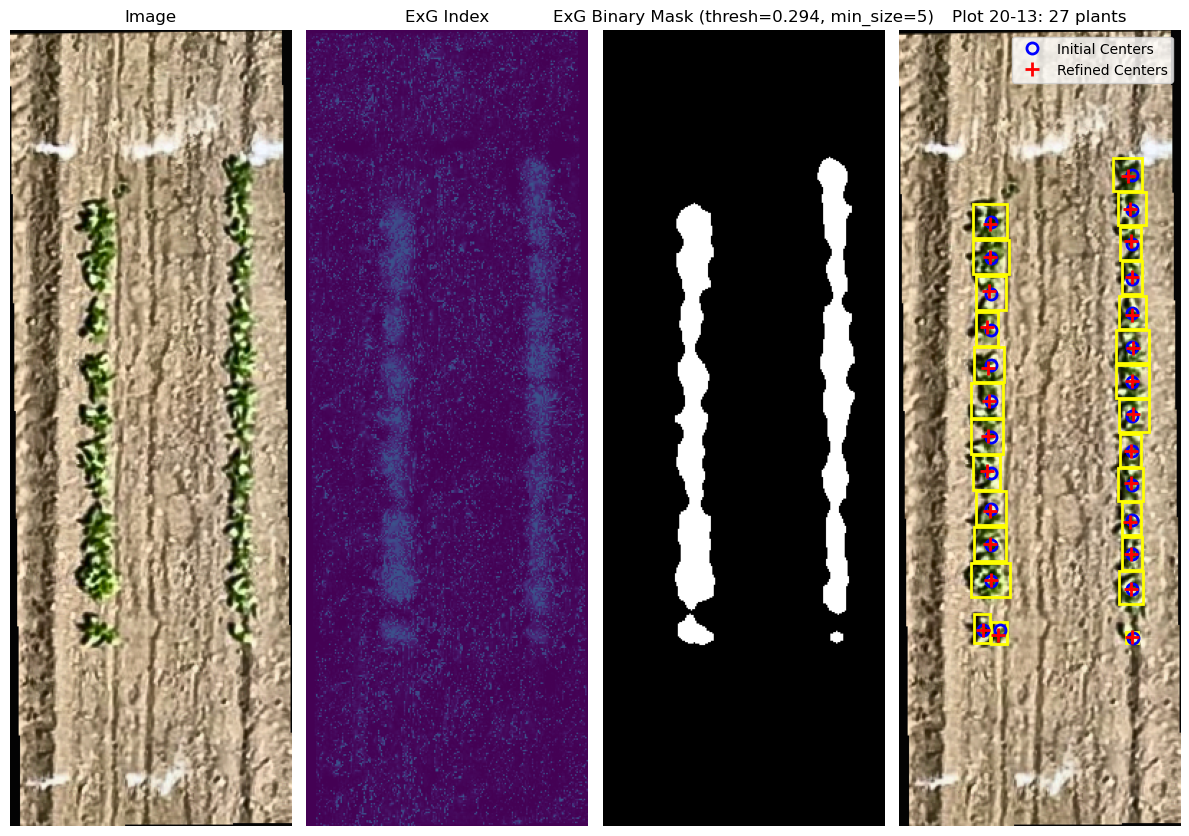

/home/lion397/codes/Image2PlantArchitecture_v2/Digital-Crops/projects/syntheticdata_generation/build_release/test2/plot_20_13_0000.jpeg


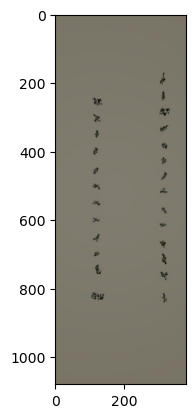

In [44]:
# Display generated image
import matplotlib.pyplot as plt
import os
from PIL import Image
from datetime import datetime
import re
# Define the planting date
dop = datetime(2025, 5, 27)

ortho_path = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"

# Parse date from ortho_path using regex to find YYYY-MM-DD pattern
date_pattern = r'(\d{4})-(\d{2})-(\d{2})'
match = re.search(date_pattern, ortho_path)

if match:
    year, month, day = match.groups()
    ortho_date = datetime(int(year), int(month), int(day))
    dap = (ortho_date - dop).days 
    print(f"Parsed ortho date: {ortho_date.strftime('%Y-%m-%d')}")
    print(f"Days after planting (DAP): {dap}")
else:
    # Fallback to manual calculation if parsing fails
    print("Warning: Could not parse date from ortho_path, using manual DAP")
    dap = (datetime(2025, 6, 17) - dop).days

ortho_path="../../../data/raw/2025_Davis/real_data/2025-06-06/Drone/2025-06-06-RGB.tif"
dem_path="../../../data/raw/2025_Davis/real_data/2025-06-06/Drone/2025-06-06-RGB.tif"
helios_path = "build_release"
#helios_path = "build_ellie"
drone_ds = DroneOrthoDataset(
    ortho_path=Path(ortho_path),
    dem_path=Path(dem_path),  # Add DEM path
    #ortho_path=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-17/Drone-5m/GOPRO/2025-06-17-RGB.tif"),
    geojson_path=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis/Plot-Boundary-WGS84.geojson"),
    program_path=helios_path,
    use_sam=False,
    debug=False
)

# Process single plot
idx = 35*14 + 10 - 1 # dap_90_plot_35_10_0000.jpeg ? 
img, meta = drone_ds[idx]
results = drone_ds.localize_plants(idx=idx, min_size=5, histogram_norm=True, use_sam=False, show=True)

# Load example params
params_path = Path("params.json")  # change to the correct filename or absolute path
if not params_path.exists():
    raise FileNotFoundError(f"JSON file not found: {params_path}")
with params_path.open("r", encoding="utf-8") as f:
    params = json.load(f)

output_dir = f"{helios_path}/test2"
params_path = drone_ds.generate_params(
    idx, 
    results, 
    params, 
    #age=dap,
    age=10,
    use_dem_ground=False,
    camera_height=1.5,
    plot_size_buffer=1.0,
    dem_scale_z=0.1,      # Smaller scale for realistic ground variation
    dem_subsample=1,       # Reduce mesh complexity
    output_dir = output_dir
)
drone_ds.run_helios(params_path, output_path=output_dir.split("/")[-1])


# Visualize the rendered image too
output_image_name = params_path.replace(".json","_0000.jpeg")
image = Image.open(output_image_name)
print(output_image_name)
plt.imshow(image)

In [ ]:
#!/usr/bin/env python3
"""
Visualization script for COCO JSON segmentation masks.
This script displays the generated image alongside the segmentation masks.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import argparse
import os

def load_classes(classes_path):
    """Load class names from classes.txt file"""
    classes = {}
    if os.path.exists(classes_path):
        with open(classes_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(maxsplit=1)
                if len(parts) == 2:
                    class_id = int(parts[0])
                    class_name = parts[1]
                    classes[class_id] = class_name
    return classes

def load_txt(txt_path, classes):
    """Load bounding boxes from YOLO format txt file"""
    boxes = []
    with open(txt_path, 'r') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line: 
                continue
            parts = line.split()
            if len(parts) < 5:
                continue
            cls_id = parts[0]
            x_c, y_c, w, h = map(float, parts[1:5])
            boxes.append((cls_id, x_c, y_c, w, h))
    return boxes

def draw_boxes(image_path, boxes, classes, out_path=None):
    im = Image.open(image_path).convert("RGBA")
    W, H = im.size
    draw = ImageDraw.Draw(im)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 14)
    except:
        font = ImageFont.load_default()

    colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]
    for i, (cls_id, x_c, y_c, w, h) in enumerate(boxes):
        if cls_id in classes:
            xc = x_c * W
            yc = y_c * H
            bw = w * W
            bh = h * H
            xmin = max(0, xc - bw/2)
            ymin = max(0, yc - bh/2)
            xmax = min(W, xc + bw/2)
            ymax = min(H, yc + bh/2)
            color = colors[int(cls_id) % len(colors)] if cls_id.isdigit() else "#FFFFFF"
            draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
            
            # Get class name if available
            class_name = classes.get(int(cls_id), cls_id) if cls_id.isdigit() else cls_id
            label = f"[{i}] {class_name}"
            
            # Use textbbox instead of textsize for newer Pillow versions
            bbox = draw.textbbox((0, 0), label, font=font)
            text_w = bbox[2] - bbox[0]
            text_h = bbox[3] - bbox[1]
            draw.rectangle([xmin, ymin - text_h - 4, xmin + text_w + 6, ymin], fill=color)
            draw.text((xmin + 3, ymin - text_h - 2), label, fill="black", font=font)

    if out_path is None:
        base, _ = os.path.splitext(image_path)
        out_path = base + "_bboxes.png"
    
    # Convert RGBA to RGB if saving as JPEG
    if out_path.lower().endswith(('.jpg', '.jpeg')):
        im = im.convert("RGB")
    
    im.save(out_path)
    print("Saved:", out_path)

    return im

def load_coco_json(json_path):
    """Load COCO JSON segmentation file"""
    with open(json_path, 'r') as f:
        return json.load(f)

def visualize_segmentation(json_path, output_path=None):
    """
    Visualize the image with segmentation masks overlayed
    
    Args:
        json_path: Path to the COCO JSON file
        output_path: Optional path to save the visualization
    """
    
    # Load JSON first to get image path
    if not os.path.exists(json_path):
        print(f"Error: JSON file not found: {json_path}")
        return
    
    coco_data = load_coco_json(json_path)
    
    # Extract image path from JSON
    if 'images' not in coco_data or len(coco_data['images']) == 0:
        print("Error: No images found in JSON file")
        return
    
    # Get image path from JSON (relative to JSON file location)
    json_dir = os.path.dirname(json_path)
    relative_image_path = coco_data['images'][0]['file_name']
    image_path = os.path.join(json_dir, relative_image_path)
    
    # Normalize the path to handle '../' correctly
    image_path = os.path.normpath(image_path)
    
    # Load image
    if not os.path.exists(image_path):
        print(f"Error: Image file not found: {image_path}")
        return
    
    image = Image.open(image_path)
    
    
    # Load classes
    classes_path = os.path.join(json_dir, "classes.txt")
    classes = load_classes(classes_path)
    if not classes:
        print(f"Warning: classes.txt not found at {classes_path}")
    
    # Load bounding boxes from txt file
    txt_path = json_path.replace("_labels.json", ".txt")
    if os.path.exists(txt_path):
        boxes = load_txt(txt_path, classes)
        if boxes:
            im = draw_boxes(image_path, boxes, {"0":"plants"})
        else:
            print("No boxes found in", txt_path)
    else:
        print(f"Warning: TXT file not found: {txt_path}")

    # Create figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))
    
    # # Show Original image
    # original_image = Image.open(image_path.replace("_0000.jpeg","_orig.png"))
    # axes[0].imshow(original_image)
    # axes[0].set_title('Original Image')
    # axes[0].axis('off')

    # Show helios image
    axes[0].imshow(image)
    axes[0].set_title('HELIOS Ditial Twin Image')
    axes[0].axis('off')
    
    # Show image with segmentation masks
    if 0:
        axes[1].imshow(image)
        axes[1].set_title('Image with Segmentation Masks')
        axes[1].axis('off')

        # Create category lookup
        categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
        
        # Colors for different categories (not annotations)
        category_colors = {
            'ground': 'red',
            'bunny': 'blue',
            # Add more colors as needed
        }
        
        # Draw segmentation masks
        for i, annotation in enumerate(coco_data['annotations']):
            # Get category name
            category_id = annotation['category_id']
            category_name = categories.get(category_id, f'Category {category_id}')
            color = category_colors.get(category_name, plt.cm.Set3(i / len(coco_data['annotations'])))
            
            # Get segmentation polygon
            segmentation = annotation['segmentation'][0]  # Assuming single polygon per annotation
            
            # Convert flat list to (x, y) pairs
            points = []
            for j in range(0, len(segmentation), 2):
                points.append([segmentation[j], segmentation[j+1]])
            
            # Create polygon patch
            polygon = Polygon(points, closed=True, alpha=0.4, facecolor=color, edgecolor='black', linewidth=2)
            axes[1].add_patch(polygon)
            
            # Get bounding box
            bbox = annotation['bbox']
            rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                                linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
            axes[1].add_patch(rect)
            
            # Add annotation ID and category as text
            axes[1].text(bbox[0], bbox[1] - 5, f"ID: {annotation['id']} ({category_name})", 
                        color='white', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7))
        
        # Add legend with annotation info
        if 0:
            legend_text = []
            for i, annotation in enumerate(coco_data['annotations']):
                category_id = annotation['category_id']
                category_name = categories.get(category_id, f'Category {category_id}')
                legend_text.append(f"ID {annotation['id']}: {category_name}, Area {annotation['area']}")
            
            if legend_text:
                axes[1].text(0.02, 0.98, '\n'.join(legend_text), transform=axes[1].transAxes,
                            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.8))
    
    # Show image with segmentation masks
    axes[1].imshow(im)
    axes[1].set_title('Image with Text Bounding Boxes')
    axes[1].axis('off')
    
    # Print summary
    print(f"Loaded image: {image.size[0]}x{image.size[1]}")
    print(f"Found {len(coco_data['annotations'])} segmentation masks")
    print(f"Categories: {[cat['name'] for cat in coco_data['categories']]}")
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to: {output_path}")
    
    #plt.show()


#visualize_segmentation("build_release/test/plot_21_3_0000_labels.json", "build_release/test/plot_21_3_0000_coco.jpeg")
#visualize_segmentation(str(helios_output_path) + "/plot_0000_labels.json", str(helios_output_path) + "/plot_0000_coco.jpeg")

In [ ]:
from datetime import datetime
import re
from tqdm.auto import tqdm
# Define the planting date
dop = datetime(2025, 5, 27)

ortho_path = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"

# Parse date from ortho_path using regex to find YYYY-MM-DD pattern
date_pattern = r'(\d{4})-(\d{2})-(\d{2})'
match = re.search(date_pattern, ortho_path)

if match:
    year, month, day = match.groups()
    ortho_date = datetime(int(year), int(month), int(day))
    dap = (ortho_date - dop).days
    print(f"Parsed ortho date: {ortho_date.strftime('%Y-%m-%d')}")
    print(f"Days after planting (DAP): {dap}")
else:
    # Fallback to manual calculation if parsing fails
    print("Warning: Could not parse date from ortho_path, using manual DAP")
    dap = (datetime(2025, 6, 17) - dop).days

ortho_path="/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"
dem_path="/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-DEM.tif"
drone_ds = DroneOrthoDataset(
    ortho_path=Path(ortho_path),
    #dem_path=Path(dem_path),  # Add DEM path
    dem_path=None,
    geojson_path=Path("/home/lion397/GEMINI/heesup/dataset/2025_Davis/Plot-Boundary-WGS84.geojson"),
    program_path="build_release",
    use_sam=False,
    debug=False
)

# Iterate over the plots
daps = [10, 30, 50, 70, 90]
#daps = [90]
for dap in daps:
    dataset_path = f"/home/lion397/GEMINI/heesup/dataset/2025_Davis/HELIOS_Prospect/"
    for idx in tqdm(range(len(drone_ds))):
        # if idx > 1:
        #     break # Dry run
        meta = drone_ds._files[idx]
        # Check if the renderd image exists
        renderd_image_name = f"dap_{dap}_plot_{meta['bed']}_{meta['row']}_0000.jpeg"

        # Debugging
        if meta['bed'] == 39 and meta['row'] == 2:
            pass
        else:
            continue

        if os.path.exists(os.path.join(dataset_path, renderd_image_name)):
            continue
        
        img, _ = drone_ds[idx]
        results = drone_ds.localize_plants(idx=idx, min_size=5, histogram_norm=True, use_sam=False, show=False)
        params_path = drone_ds.generate_params(
            idx, 
            results, 
            params, 
            age=dap,
            use_dem_ground=False,
            dem_scale_z=0.1,      # Smaller scale for realistic ground variation
            dem_subsample=1,       # Reduce mesh complexity
            output_dir = dataset_path,
            output_suffix=f"dap_{dap}"
        )
        drone_ds.run_helios(params_path, output_path=dataset_path, seed=idx)

Parsed ortho date: 2025-06-06
Days after planting (DAP): 10


100%|█████████████████████████████████████| 560/560 [00:00<00:00, 520569.65it/s]


In [9]:
import os
import json
import subprocess
import copy
from datetime import datetime
from tqdm.auto import tqdm
import numpy as np

# Load example params
params_path = Path("params.json")  # change to the correct filename or absolute path
if not params_path.exists():
    raise FileNotFoundError(f"JSON file not found: {params_path}")

with params_path.open("r", encoding="utf-8") as f:
    params = json.load(f)

print("Loaded params:", params.keys())

# Generate 10 randomized genotypes
genotypes = []
np.random.seed(42)
for i in range(10):
    # Generate min and max values ensuring min < max
    plant_count_min = int(np.random.uniform(3, 8))
    plant_count_max = int(np.random.uniform(plant_count_min + 1, 15))
    
    spacing_x_min = np.random.uniform(0.3, 0.5)
    spacing_x_max = np.random.uniform(spacing_x_min + 0.1, 1.0)
    
    spacing_y_min = np.random.uniform(0.3, 0.6)
    spacing_y_max = np.random.uniform(spacing_y_min + 0.2, 1.4)
    
    leaf_pitch_min = np.random.uniform(-120.0, -60.0)
    leaf_pitch_max = np.random.uniform(60.0, 120.0)
    
    flower_bud_min = np.random.uniform(0.0, 0.2)
    flower_bud_max = np.random.uniform(flower_bud_min + 0.4, 1.0)
    
    chlorophyll_min = np.random.uniform(1.0, 20.0)
    chlorophyll_max = np.random.uniform(chlorophyll_min + 10.0, 60.0)
    
    carotenoid_min = np.random.uniform(5.0, 10.0)
    carotenoid_max = np.random.uniform(carotenoid_min + 2.0, 20.0)
    
    genotype = {
        "plant_count": {"min": plant_count_min, "max": plant_count_max},
        "plant_spacing_x": {"min": spacing_x_min, "max": spacing_x_max},
        "plant_spacing_y": {"min": spacing_y_min, "max": spacing_y_max},
        "leaf_pitch": {"min": leaf_pitch_min, "max": leaf_pitch_max},
        "flower_bud_break_probability": {"min": flower_bud_min, "max": flower_bud_max},
        "chlorophyll_content": {"min": chlorophyll_min, "max": chlorophyll_max},
        "carotenoid_content": {"min": carotenoid_min, "max": carotenoid_max}
    }
    genotypes.append(genotype)

num_scenes = 10  # Number of random scenes per genotype per DAP

# Iterate over genotypes
for genotype_idx, genotype in enumerate(genotypes):
    # Randomize camera height
    camera_height = np.random.uniform(1.0, 10.0)
    
    # Iterate over DAPs
    daps = list(range(10, 121, 10))
    for dap in daps:
        dataset_path = f"/home/lion397/GEMINI/heesup/dataset/2025_Davis/HELIOS_virtual_genotype_prospect/"
        os.makedirs(dataset_path, exist_ok=True)
        
        for scene_idx in tqdm(range(num_scenes), desc=f"Genotype {genotype_idx}, DAP {dap}"):
            # Randomize plant locations using genotype distributions
            num_plants = np.random.randint(genotype["plant_count"]["min"], genotype["plant_count"]["max"] + 1)
            
            # Determine grid layout
            num_rows = np.random.randint(1, 5)
            num_cols = max(1, (num_plants + num_rows - 1) // num_rows)  # Ceiling division
            
            plants = []
            plant_idx = 0
            for row in range(num_rows):
                for col in range(num_cols):
                    if plant_idx >= num_plants:
                        break
                    
                    spacing_x = np.random.uniform(genotype["plant_spacing_x"]["min"], genotype["plant_spacing_x"]["max"])
                    spacing_y = np.random.uniform(genotype["plant_spacing_y"]["min"], genotype["plant_spacing_y"]["max"])
            
                    x = col * spacing_x - (num_cols - 1) * spacing_x / 2
                    y = row * spacing_y - (num_rows - 1) * spacing_y / 2
                    plants.append({
                        "bed": 1,
                        "row": 1,
                        "x": float(x),
                        "y": float(y),
                        "z": 0.0,
                        "xml": ""
                    })
                    plant_idx += 1

            # Compute ground size to cover all plant locations
            if plants:
                xs = [plant['x'] for plant in plants]
                ys = [plant['y'] for plant in plants]
                min_x, max_x = min(xs), max(xs)
                min_y, max_y = min(ys), max(ys)
                margin = np.random.uniform(0.5, 2.0)
                size_x = max_x - min_x + margin
                size_y = max_y - min_y + margin
            else:
                size_x = 2.5
                size_y = 5.0
            
            # Calculate required FOV and resolution
            area = 1280 * 720
            res_x = int(np.round(np.sqrt(area * size_x / size_y)))
            res_y = int(np.round(size_y / size_x * res_x))
            res_x = int(np.round(res_y * size_x / size_y))
            HFOV_deg, VFOV_deg = calculate_required_fov(camera_height, size_x, size_y, res_x, res_y)
            
            # Build params with new structure
            scene_params = {
                "seed": np.random.randint(0, 10000),
                "field": {
                    "year": 2025,
                    "location": "drone_ortho",
                    "plant_type": "cowpea",
                    "plant_age": dap,
                    "plot_shape": {
                        "plot_height": 0.2,
                        "plot_width": float(size_x),
                        "plot_length": float(size_y),
                        "plot_heading": 0,
                        "soil_color": [0.61, 0.58, 0.55],
                        "use_obj_ground": False,
                        "obj_file_path": "../../../obj/dirt_rocks.obj",
                        "specular_exponent": float(np.random.uniform(2.0, 4.0)),
                        "size_x": float(size_x),
                        "size_y": float(size_y)
                    },
                    "mode": "manual",
                    "plants": plants,
                    "num_beds": 1,
                    "num_rows": 1
                },
                "sun_position": {
                    "elevation_degrees": float(np.random.uniform(0, 90)),
                    "azimuth_degrees": float(np.random.uniform(0, 360)),
                    "shadow": True
                },
                "plantarchitecture": {
                    "phytomer_parameters": {
                        "leaf_pitch": float(np.random.uniform(genotype["leaf_pitch"]["min"], genotype["leaf_pitch"]["max"]))
                    },
                    "flower_bud_break_probability": float(np.random.uniform(genotype["flower_bud_break_probability"]["min"], genotype["flower_bud_break_probability"]["max"]))
                },
                "cameraproperties": {
                    "camera_height": float(camera_height),
                    "focal_plane_distance_difference": 0.5,
                    "lens_diameter": 0.0028,
                    "HFOV": float(HFOV_deg),
                    "camera_resolution_x": res_x,
                    "camera_resolution_y": res_y,
                    "camera_positioning": {
                        "distance_from_center": 0.01,
                        "center_plants": False,
                        "azimuth_angle": 0,
                        "lookat_offset_x": 0.0,
                        "lookat_offset_y": 0.0,
                        "lookat_offset_z": 0.0
                    }
                },
                "radiationmodel": {
                    "bandlabels": ["red", "green", "blue"],
                    "cameralabel": "camera",
                    "soil_surface_spectral_data": {
                        "reflectivity": f"soil_reflectivity_{np.random.randint(0, 4):04d}"
                    },
                    "camera_spectral_data": {
                        "camera_type": "Basler_acA2500-20gc"
                    }
                },
                "leafoptics": {
                    "number_layers": float(np.random.uniform(1.2, 2.0)),
                    "chlorophyll_content": float(np.random.uniform(genotype["chlorophyll_content"]["min"], genotype["chlorophyll_content"]["max"])),
                    "carotenoid_content": float(np.random.uniform(genotype["carotenoid_content"]["min"], genotype["carotenoid_content"]["max"])),
                    "anthocyan_content": float(np.random.uniform(0.0, 2.0)),
                    "brown_pigments": float(np.random.uniform(0.0, 0.5)),
                    "water_mass": float(np.random.uniform(0.005, 0.025)),
                    "dry_mass": float(np.random.uniform(0.001, 0.01)),
                    "protein": 0.0,
                    "carbon_constituents": 0.0,
                    "specular_exponent": float(np.random.uniform(1.0, 5.0))
                }
            }
            
            # Generate params file
            params_name = f"genotype_{genotype_idx}_dap_{dap}_scene_{scene_idx}.json"
            expected_image_name = params_name.replace(".json", "_0000.jpeg")
            if os.path.exists(os.path.join(dataset_path, expected_image_name)):
                continue

            params_file = os.path.join(dataset_path, params_name)
            with open(params_file, 'w') as f:
                json.dump(scene_params, f, indent=2)
            
            # Run HELIOS
            command = ["./main", "-f", params_file, "--xml", "-o", dataset_path, "-n", params_name.split(".")[0]]
            result = subprocess.run(command, cwd="./build_release/", capture_output=True, text=True)
            if result.returncode != 0:
                print(f"Error running HELIOS for genotype {genotype_idx}, DAP {dap}, scene {scene_idx}: {result.stderr}")
            else:
                print(f"Successfully generated for genotype {genotype_idx}, DAP {dap}, scene {scene_idx}")


Loaded params: dict_keys(['seed', 'field', 'sun_position', 'plantarchitecture', 'cameraproperties', 'radiationmodel', 'leafoptics'])


Genotype 9, DAP 120: 100%|████████████████████| 10/10 [00:00<00:00, 1968.79it/s]


In [8]:
params_file = "/home/lion397/codes/Image2PlantArchitecture_v2/data/raw/2025_Davis/HELIOS_virtual_genotype/genotype_8_dap_90_scene_0_0000_labels.json"
output_image = params_file.replace("_labels.json", "_coco.jpeg")

visualize_segmentation(params_file, output_image)

Error: JSON file not found: /home/lion397/codes/Image2PlantArchitecture_v2/data/raw/2025_Davis/HELIOS_virtual_genotype/genotype_8_dap_90_scene_0_0000_labels.json
